In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import xml.etree.ElementTree as ET
import torch
from sklearn.metrics import (average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt



In [ ]:
TARGET_FRAMES = 32
COORD_FEATURES = 9
VISUAL_FEATURES = 256 

ALL_VIDEO_SEQ = [("../data/Video_1/Video.xml",
                  "../data/Video_1/calib_cam_to_cam.txt",
                  "../data/Video_1/calib_imu_to_velo.txt",
                  "../data/Video_1/calib_velo_to_cam.txt", "../data/Video_1/sequence_images/", "Video_1"), ("../data/Video_2/Video.xml",
                                                                                                            "../data/Video_2/calib_cam_to_cam.txt",
                                                                                                            "../data/Video_2/calib_imu_to_velo.txt",
                                                                                                            "../data/Video_2/calib_velo_to_cam.txt", "../data/Video_2/sequence_images/", "Video_2"),
                 ("../data/Video_3/Video.xml",
                  "../data/Video_3/calib_cam_to_cam.txt",
                  "../data/Video_3/calib_imu_to_velo.txt",
                  "../data/Video_3/calib_velo_to_cam.txt", "../data/Video_3/sequence_images/", "Video_3"),
                 ("../data/Video_4/Video.xml",
                  "../data/Video_4/calib_cam_to_cam.txt",
                  "../data/Video_4/calib_imu_to_velo.txt",
                  "../data/Video_4/calib_velo_to_cam.txt", "../data/Video_4/sequence_images/", "Video_4"),
                 ("../data/Video_9/Video.xml",
                  "../data/Video_9/calib_cam_to_cam.txt",
                  "../data/Video_9/calib_imu_to_velo.txt",
                  "../data/Video_9/calib_velo_to_cam.txt", "../data/Video_9/sequence_images/", "Video_9"),

                 ("../data/Video_10/Video.xml",
                  "../data/Video_10/calib_cam_to_cam.txt",
                  "../data/Video_10/calib_imu_to_velo.txt",
                  "../data/Video_10/calib_velo_to_cam.txt", "../data/Video_10/sequence_images/", "Video_10"),

                 ("../data/Video_11/Video.xml",
                  "../data/Video_11/calib_cam_to_cam.txt",
                  "../data/Video_11/calib_imu_to_velo.txt",
                  "../data/Video_11/calib_velo_to_cam.txt", "../data/Video_11/sequence_images/", "Video_11"),

                 ("../data/Video_12/Video.xml",
                  "../data/Video_12/calib_cam_to_cam.txt",
                  "../data/Video_12/calib_imu_to_velo.txt",
                  "../data/Video_12/calib_velo_to_cam.txt", "../data/Video_12/sequence_images/", "Video_12"),

                 ("../data/Video_13/Video.xml",
                  "../data/Video_13/calib_cam_to_cam.txt",
                  "../data/Video_13/calib_imu_to_velo.txt",
                  "../data/Video_13/calib_velo_to_cam.txt", "../data/Video_13/sequence_images/", "Video_13"),
                 ]

NUM_CLASSES = 5
CLASS_MAP = {'Car': 0, 'Van': 1, 'Truck': 2, 'Pedestrian': 3, 'Cyclist': 4}
INV_CLASS_MAP = {v: k for k, v in CLASS_MAP.items()}

In [ ]:
train_set = ALL_VIDEO_SEQ[0:7] 
val_set   = ALL_VIDEO_SEQ[7:8]
test_set  = ALL_VIDEO_SEQ[8:9]

print(f'Train sequences : {len(train_set)}')
print(f'Val   sequences : {len(val_set)}')
print(f'Test  sequences : {len(test_set)}')


Train sequences : 7
Val   sequences : 1
Test  sequences : 1


In [ ]:
def check_data_paths(img_root='data'):
    all_ok = True
    for xml_path, cam_to_cam, imu_to_velo, velo_to_cam, images_dir, name in ALL_VIDEO_SEQ:
        print(xml_path, cam_to_cam, imu_to_velo, velo_to_cam, images_dir, name)
        video_name = name
        img_dir    = images_dir

        xml_ok   = os.path.isfile(xml_path)
        c2c_ok   = os.path.isfile(cam_to_cam)
        i2v_ok   = os.path.isfile(imu_to_velo)
        v2c_ok   = os.path.isfile(velo_to_cam)
        img_ok   = os.path.isdir(img_dir)
        n_images = len([f for f in os.listdir(img_dir) if f.endswith('.png')]) if img_ok else 0

        status = '✓' if all([xml_ok, c2c_ok, i2v_ok, v2c_ok, img_ok]) else '✗'
        if status == '✗':
            all_ok = False
        print(f'{status}  {video_name}  |  xml={xml_ok}  c2c={c2c_ok}  '
              f'i2v={i2v_ok}  v2c={v2c_ok}  imgs={n_images} ({img_dir})')

    if all_ok:
        print('\nAll paths verified')
    else:
        print('\n One or more paths are missing')

check_data_paths()

../data/Video_1/Video.xml ../data/Video_1/calib_cam_to_cam.txt ../data/Video_1/calib_imu_to_velo.txt ../data/Video_1/calib_velo_to_cam.txt ../data/Video_1/sequence_images/ Video_1
✓  Video_1  |  xml=True  c2c=True  i2v=True  v2c=True  imgs=0 (../data/Video_1/sequence_images/)
../data/Video_2/Video.xml ../data/Video_2/calib_cam_to_cam.txt ../data/Video_2/calib_imu_to_velo.txt ../data/Video_2/calib_velo_to_cam.txt ../data/Video_2/sequence_images/ Video_2
✓  Video_2  |  xml=True  c2c=True  i2v=True  v2c=True  imgs=77 (../data/Video_2/sequence_images/)
../data/Video_3/Video.xml ../data/Video_3/calib_cam_to_cam.txt ../data/Video_3/calib_imu_to_velo.txt ../data/Video_3/calib_velo_to_cam.txt ../data/Video_3/sequence_images/ Video_3
✓  Video_3  |  xml=True  c2c=True  i2v=True  v2c=True  imgs=433 (../data/Video_3/sequence_images/)
../data/Video_4/Video.xml ../data/Video_4/calib_cam_to_cam.txt ../data/Video_4/calib_imu_to_velo.txt ../data/Video_4/calib_velo_to_cam.txt ../data/Video_4/sequence_im

In [ ]:
def _parse_calib_file(path):
    calib = {}
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or ':' not in line:
                continue
            key, vals = line.split(':', 1)
            try:
                calib[key.strip()] = np.array([float(v) for v in vals.split()])
            except ValueError:
                pass 
    return calib   

In [ ]:
def get_projection_matrix(cam_to_cam_path, velo_to_cam_path):
    vc = _parse_calib_file(velo_to_cam_path)
    R_vc = vc['R'].reshape(3, 3)
    T_vc = vc['T'].reshape(3, 1)
    tr_velo_to_cam = np.vstack([np.hstack([R_vc, T_vc]), [0, 0, 0, 1]])  

    cc = _parse_calib_file(cam_to_cam_path)
    r_rect = np.eye(4)
    r_rect[:3, :3] = cc['R_rect_00'].reshape(3, 3)
    p_rect_02 = cc['P_rect_02'].reshape(3, 4)

    return p_rect_02 @ r_rect @ tr_velo_to_cam

In [ ]:
def project_3d_to_2d(p_matrix, x, y, z):
    pt_3d = np.array([x, y, z, 1.0])
    pt_2d = p_matrix @ pt_3d
    if pt_2d[2] == 0:
        return 0, 0
    return int(pt_2d[0] / pt_2d[2]), int(pt_2d[1] / pt_2d[2])

In [5]:
class VisionExtractor:
    def __init__(self):
        full_model = fasterrcnn_resnet50_fpn(pretrained=True)
        self.backbone = full_model.backbone
        self.backbone.eval()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.backbone.to(self.device)
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 224, 224).to(self.device)
            self.feature_dim = self.backbone(dummy)['0'].shape[1]
        self.transform = T.Compose([
            T.Resize((224, 224)), T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

    def extract(self, pil_img):
        img_t = self.transform(pil_img).unsqueeze(0).to(self.device)
        with torch.no_grad():
            feats = self.backbone(img_t)
            return torch.mean(feats['0'], dim=[2, 3]).cpu().numpy().flatten()

In [ ]:
class KITTIDataset(Dataset):
    def __init__(self, sequences, extractor,set, augment=False,):
        self.sequences = sequences
        self.extractor = extractor
        self.set = set
        self.augment   = augment
        self.X, self.y = self._build()   

  
    def __len__(self):
        return len(self.y)

    def __getitem__(self):
        pass

    def _build(self):
        all_X, all_y = [], []

        for xml_path, cam_to_cam, _, velo_to_cam, images_dir, name in self.sequences:

            p_mat = get_projection_matrix(cam_to_cam, velo_to_cam)
            tracklets = self._parse_xml(xml_path)

            for label, frames in tracklets:
                if label not in CLASS_MAP:
                    continue

                seq = self._build_sequence(frames, images_dir)

                all_X.append(seq)
                all_y.append(CLASS_MAP[label])

        all_X = np.array(all_X, dtype=np.float32)
        all_y = np.array(all_y, dtype=np.int64)

        np.save(f"../data/numpy_files/all_X_{self.set}.npy", all_X)
        np.save(f"../data/numpy_files/all_y_{self.set}.npy", all_y)

        return all_X, all_y
    

    def _parse_xml(self, xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        tracklets = []
        for obj in root.findall('.//item'):
            label  = obj.findtext('objectType', default='').strip()
            frames = []
            for frame_idx, pose in enumerate(obj.findall('.//item')):
                tx = float(pose.findtext('tx', '0'))
                ty = float(pose.findtext('ty', '0'))
                tz = float(pose.findtext('tz', '0'))
                rx = float(pose.findtext('rx', '0'))
                ry = float(pose.findtext('ry', '0'))
                rz = float(pose.findtext('rz', '0'))
                w  = float(obj.findtext('w', '0'))
                h  = float(obj.findtext('h', '0'))
                l  = float(obj.findtext('l', '0'))
                frames.append(dict(tx=tx, ty=ty, tz=tz,
                                   rx=rx, ry=ry, rz=rz,
                                   w=w,   h=h,   l=l,
                                   frame_idx=frame_idx)) 
            if frames:
                tracklets.append((label, frames))
        return tracklets

    def _build_sequence(self, frames, images_dir):
        
        if len(frames) >= TARGET_FRAMES:
            if self.augment:
                start = np.random.randint(0, len(frames) - TARGET_FRAMES + 1)
            else:
                start = 0
            frames = frames[start: start + TARGET_FRAMES]
        else:
            pad    = [frames[-1]] * (TARGET_FRAMES - len(frames))
            frames = frames + pad

        seq = []
        for f in frames:
            coord = np.array([f['tx'], f['ty'], f['tz'],
                               f['rx'], f['ry'], f['rz'],
                               f['w'],  f['h'],  f['l']], dtype=np.float32)
            img_path = os.path.join(images_dir, f"{f['frame_idx']:010d}.png")
            if os.path.exists(img_path):
                pil_img = Image.open(img_path).convert('RGB')
                vis = self.extractor.extract(pil_img).astype(np.float32)
            else:
                vis = np.zeros(self.extractor.feature_dim, dtype=np.float32)
            seq.append(np.concatenate([coord, vis]))

        return np.stack(seq) 



In [ ]:
def make_datasets(extractor):
    
    print('Building TRAIN dataset ...')
    train_ds = KITTIDataset(train_set, extractor, augment=True,set="train")

    print('Building VAL   dataset ...')
    val_ds   = KITTIDataset(val_set,   extractor, augment=False,set="valdation")

    print('Building TEST  dataset ...')
    test_ds  = KITTIDataset(test_set,  extractor, augment=False,set="test")

    print(f'  train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)} tracklets')

    return train_ds, val_ds, test_ds


In [ ]:
class TemporalFPNBlock(layers.Layer):
    def __init__(self, out_channels: int = 128, **kwargs):
        super().__init__(**kwargs)
        self.out_channels = out_channels

        self.p3_conv = layers.Conv1D(out_channels, 3, padding='same',
                                     dilation_rate=1, activation='relu', name='p3_conv')
        self.p4_conv = layers.Conv1D(out_channels, 3, padding='same',
                                     dilation_rate=2, activation='relu', name='p4_conv')
        self.p5_conv = layers.Conv1D(out_channels, 3, padding='same',
                                     dilation_rate=4, activation='relu', name='p5_conv')

        self.lat_p4  = layers.Conv1D(out_channels, 1, padding='same', name='lat_p4')
        self.lat_p3  = layers.Conv1D(out_channels, 1, padding='same', name='lat_p3')

        self.merge_p4 = layers.Conv1D(out_channels, 3, padding='same',
                                      activation='relu', name='merge_p4')
        self.merge_p3 = layers.Conv1D(out_channels, 3, padding='same',
                                      activation='relu', name='merge_p3')

        self.out_proj = layers.Conv1D(out_channels, 1, padding='same', name='fpn_out')
        self.bn_out   = layers.BatchNormalization(name='fpn_bn')

    def call(self, x, training=False):
        p3 = self.p3_conv(x) 
        p4 = self.p4_conv(x)
        p5 = self.p5_conv(x)

        p4_td = self.merge_p4(self.lat_p4(p4) + p5)

        p3_td = self.merge_p3(self.lat_p3(p3) + p4_td)

        out = self.bn_out(self.out_proj(p3_td), training=training)
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'out_channels': self.out_channels})
        return cfg


In [ ]:
def plot_training_metrics(history):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    ax[0].plot(history.history['accuracy'],     label='Train')
    ax[0].plot(history.history['val_accuracy'], label='Val')
    ax[0].set_title('Model Accuracy')
    ax[0].set_xlabel('Epoch'); ax[0].legend()

    ax[1].plot(history.history['loss'],     label='Train')
    ax[1].plot(history.history['val_loss'], label='Val')
    ax[1].set_title('Model Loss')
    ax[1].set_xlabel('Epoch'); ax[1].legend()

    plt.tight_layout(); plt.show()

In [ ]:
def plot_cm(y_true, y_pred, title='Confusion Matrix'):
    y_true_labels = np.array(y_true).flatten().astype(int)
    y_pred_labels = np.argmax(y_pred, axis=1)
    cm   = confusion_matrix(y_true_labels, y_pred_labels,
                             labels=list(CLASS_MAP.values()))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=list(CLASS_MAP.keys()))
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.tight_layout(); plt.show()
  

In [ ]:
def visualize_inference(img_path, p_matrix, tx, ty, tz, pred_idx, true_idx):
    """Project a predicted tracklet centre onto the image and display it."""
    img = cv2.imread(img_path)
    if img is None:
        print(f'Image not found: {img_path}')
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    u, v = project_3d_to_2d(p_matrix, tx, ty, tz)

    color      = (0, 255, 0) if pred_idx == true_idx else (255, 0, 0)
    cv2.circle(img, (u, v), 8, color, -1)
    label_text = f"Pred: {INV_CLASS_MAP[pred_idx]} | True: {INV_CLASS_MAP[true_idx]}"
    cv2.putText(img, label_text, (u - 60, v - 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

In [ ]:
extractor = VisionExtractor()
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_datasets(extractor)

c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Building TRAIN dataset ...
Building VAL   dataset ...
Building TEST  dataset ...
  train=246  val=20  test=27 tracklets


In [22]:
# load numpy files
X_train = np.load(file="../data/numpy_files/all_X_train.npy")   # Videos 9 & 10
y_train = np.load(file="../data/numpy_files/all_y_train.npy")
X_val = np.load(file="../data/numpy_files/all_X_valdation.npy")
y_val = np.load(file="../data/numpy_files/all_y_valdation.npy")
X_test = np.load(file="../data/numpy_files/all_X_test.npy")
y_test = np.load(file="../data/numpy_files/all_y_test.npy")

In [23]:
print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}    y_val  : {y_val.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

X_train: (246, 32, 265)  y_train: (246,)
X_val  : (20, 32, 265)    y_val  : (20,)
X_test : (27, 32, 265)   y_test : (27,)


In [ ]:
def build_model():
    inp = layers.Input(shape=(TARGET_FRAMES, COORD_FEATURES + VISUAL_FEATURES),
                       name='sequence_input')

    x = layers.Conv1D(128, kernel_size=3, padding='same',
                      activation='relu', name='prefix_conv')(inp)
    x = layers.BatchNormalization(name='prefix_bn')(x)

    x = TemporalFPNBlock(out_channels=128, name='temporal_fpn')(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True),
                             name='bilstm_1')(x)
    x = layers.Bidirectional(layers.LSTM(64), name='bilstm_2')(x)

    x = layers.Dense(128, activation='relu', name='fc_head')(x)
    
    x = layers.Dropout(0.5, name='dropout')(x)
    
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

    model = models.Model(inp, out, name='3D-ResNet-Temporal-Stacking-LSTM')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [29]:
print("Building Model")
model = build_model()
model.summary()

Building Model


Model: "3D-ResNet-Temporal-Stacking-LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 32, 265)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prefix_conv (Conv1D)            │ (None, 32, 128)        │       101,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prefix_bn (BatchNormalization)  │ (None, 32, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_fpn (TemporalFPNBlock) │ (None, 32, 128)        │       296,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 32, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_head (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 843,525 (3.22 MB)

 Trainable params: 843,013 (3.22 MB)

 Non-trainable params: 512 (2.00 KB)

In [30]:
cb = [
    callbacks.EarlyStopping(monitor='val_loss', patience=50,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss',
                               save_best_only=True, verbose=1),
]

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=cb,
)


Epoch 1/100
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6101 - loss: 1.1864
Epoch 1: val_loss improved from None to 1.23762, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 404ms/step - accuracy: 0.7439 - loss: 0.9679 - val_accuracy: 0.6500 - val_loss: 1.2376 - learning_rate: 0.0010
Epoch 2/100
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8271 - loss: 0.6441
Epoch 2: val_loss did not improve from 1.23762
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8171 - loss: 0.6012 - val_accuracy: 0.6500 - val_loss: 1.2540 - learning_rate: 0.0010
Epoch 3/100
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8269 - loss: 0.5050
Epoch 3: val_loss did not improve from 1.23762
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8293 - loss: 0.5238 - val_accuracy: 0.6500 - val_loss: 1.3755 - learning_rate: 0.0010
Epoch 4/100
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8504 - loss: 0.3750
Epoch 4: val_loss di

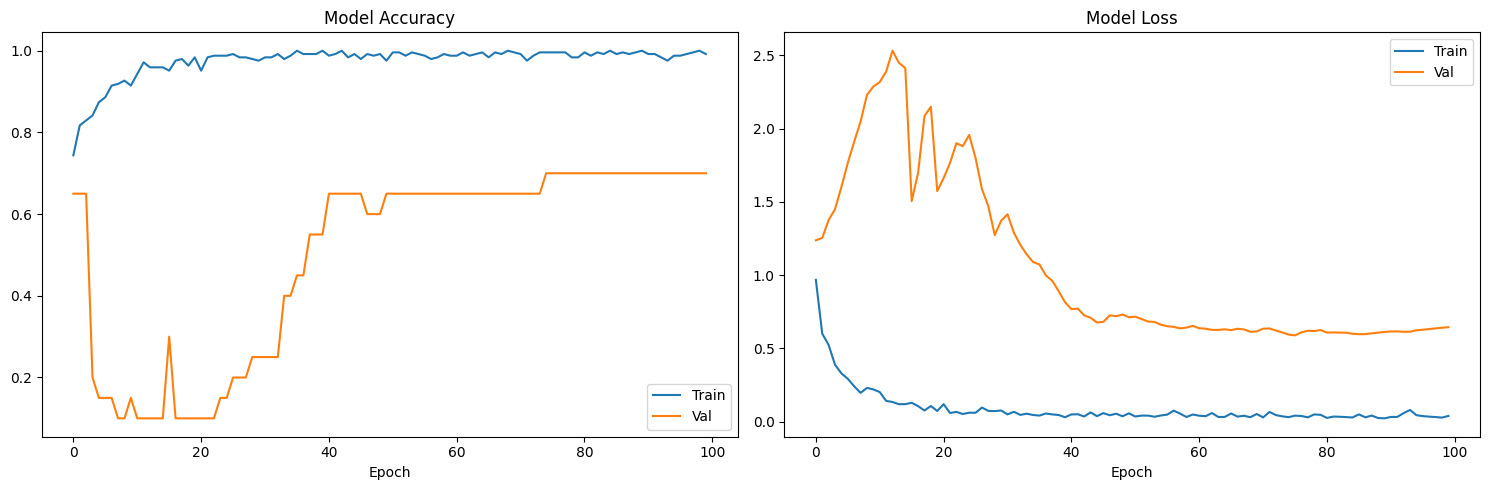


── Val split (Videos 11 & 12) ──
  Loss: 0.5893  Accuracy: 0.7000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


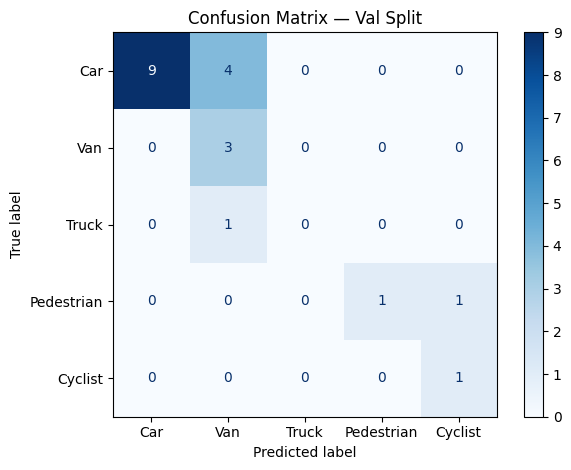

              precision    recall  f1-score   support

         Car       1.00      0.69      0.82        13
         Van       0.38      1.00      0.55         3
       Truck       0.00      0.00      0.00         1
  Pedestrian       1.00      0.50      0.67         2
     Cyclist       0.50      1.00      0.67         1

    accuracy                           0.70        20
   macro avg       0.57      0.64      0.54        20
weighted avg       0.83      0.70      0.71        20



c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

In [ ]:
plot_training_metrics(history)

print('\n── Val split (Videos 11 & 12) ──')
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f'  Loss: {val_loss:.4f}  Accuracy: {val_acc:.4f}')

y_val_pred = model.predict(X_val)
plot_cm(y_val, y_val_pred, title='Confusion Matrix — Val Split')
print(classification_report(
    y_val,
    np.argmax(y_val_pred, axis=1),
    labels=list(CLASS_MAP.values()),
    target_names=list(CLASS_MAP.keys())))



── Test split (Video 13) ──
  Loss: 0.9612  Accuracy: 0.7778
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


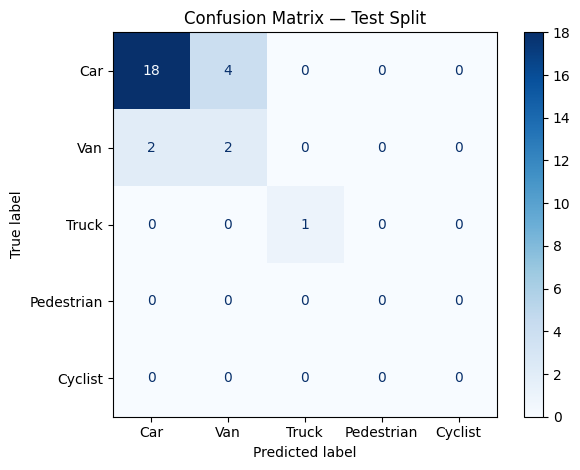

              precision    recall  f1-score   support

         Car       0.90      0.82      0.86        22
         Van       0.33      0.50      0.40         4
       Truck       1.00      1.00      1.00         1
  Pedestrian       0.00      0.00      0.00         0
     Cyclist       0.00      0.00      0.00         0

    accuracy                           0.78        27
   macro avg       0.45      0.46      0.45        27
weighted avg       0.82      0.78      0.79        27



c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted sample

In [ ]:
print('\n── Test split (Video 13) ──')
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'  Loss: {test_loss:.4f}  Accuracy: {test_acc:.4f}')

y_test_pred = model.predict(X_test)
plot_cm(y_test, y_test_pred, title='Confusion Matrix — Test Split')
print(classification_report(
    y_test,
    np.argmax(y_test_pred, axis=1),
    labels=list(CLASS_MAP.values()),
    target_names=list(CLASS_MAP.keys())))


In [34]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

# Binarise integer ground-truth labels for one-vs-rest AP calculation
y_test_bin = label_binarize(y_test, classes=list(CLASS_MAP.values()))  # (N, NUM_CLASSES)

ap_per_class = {}
for cls_idx, cls_name in INV_CLASS_MAP.items():
    ap = average_precision_score(y_test_bin[:, cls_idx], y_test_pred[:, cls_idx])
    ap_per_class[cls_name] = ap
    print(f'  AP  {cls_name:<12}: {ap:.4f}')

# Class support counts for weighted mAP
from collections import Counter
support = Counter(y_test.tolist())
total   = sum(support.values())
weighted_map = sum(ap_per_class[INV_CLASS_MAP[c]] * support[c] / total
                   for c in range(NUM_CLASSES))
print(f'\nWeighted mAP: {weighted_map:.4f}')


  AP  Car         : 0.8529
  AP  Van         : 0.3026
  AP  Truck       : 1.0000
  AP  Pedestrian  : 0.0000
  AP  Cyclist     : 0.0000

Weighted mAP: 0.7769


c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Users\kumbi\OneDrive\Documents\GitHub\3D-ResNet-Temporal-Stacking-LSTM\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


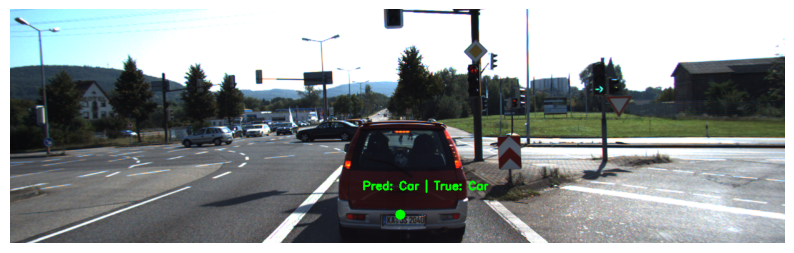

In [ ]:
SAMPLE_IDX = 0
xml_path, cam_to_cam, _, velo_to_cam, images_dir, video_name = test_set[0]
p_matrix = get_projection_matrix(cam_to_cam, velo_to_cam)

pred_idx = int(np.argmax(y_test_pred[SAMPLE_IDX]))
true_idx = int(y_test[SAMPLE_IDX])

frame_idx = 0
img_path  = os.path.join(images_dir, f'{frame_idx:010d}.png')

tx, ty, tz = X_test[SAMPLE_IDX, 0, 0], X_test[SAMPLE_IDX, 0, 1], X_test[SAMPLE_IDX, 0, 2]

visualize_inference(img_path, p_matrix, tx, ty, tz, pred_idx, true_idx)
